In [1]:
!pip install PyMuPDF tqdm aiolimiter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 90.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from spacy.lang.en import English
import fitz
import random
from tqdm.auto import tqdm
from time import perf_counter as timer
import textwrap
from sentence_transformers import util, SentenceTransformer
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoProcessor, AutoModelForVision2Seq
from PIL import Image
import requests
import ast
from langchain.text_splitter import TokenTextSplitter
from transformers import MllamaForConditionalGeneration, AutoProcessor
from typing import List, Dict, Tuple
from torch.nn.functional import normalize
import time, statistics, asyncio, tiktoken, openai
import nest_asyncio
from google.colab import userdata
from aiolimiter import AsyncLimiter
from google.colab import drive
drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mounted at /content/drive


## 1. Document/text processing and embedding creation

Steps:
1. Import PDF document.
2. Process text for embedding (e.g. split into chunks of sentences).
3. Embed text chunks with embedding model.
4. Save embeddings to file for later.


In [3]:
#Testing on one document first
pdf_path = '/content/drive/MyDrive/fMRIwork/ales.pdf'

if not os.path.exists(pdf_path):
  raise FileNotFoundError(f"PDF file not found at path: {pdf_path}")

In [4]:
def text_formatter(text: str) -> str:
  """ Does minor formatting on text """
  cleaned_text = text.replace("\n", " ").strip()
  return cleaned_text

def open_and_read_pdf(pdf_path: str) -> str:

  doc = fitz.open(pdf_path)
  pages_and_text = []
  for page_num,page in tqdm(enumerate(doc)):
    text = page.get_text()
    text = text_formatter(text)
    pages_and_text.append({"page_number": page_num,
                           "page_char_count": len(text),
                           "page_word_count": len(text.split(" ")),         # rough word count
                           "page_setence_count_raw": len(text.split(". ")), # rough sentence count
                           "page_token_count": len(text) / 4, # 1 token = ~4 characters ~ rough token count
                           "text": text})

  return pages_and_text

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

0it [00:00, ?it/s]

[{'page_number': 0,
  'page_char_count': 4142,
  'page_word_count': 627,
  'page_setence_count_raw': 29,
  'page_token_count': 1035.5,
  'text': 'Page 1 of 4 © Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.   Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 Introduction In the United States, gallstone disease remains a prevalent  condition affecting over 20 to 25 million Americans,  representing 10–15% of the population (1,2). Although not  every patient with gallstones will manifest symptoms or  require intervention, laparoscopic cholecystectomy (LC),  which accounts for 90% of all cholecystectomies, remains  one of the most commonly performed procedures— conservatively numbering 750,000 per year (3). Since its  introduction in the 1980s and subsequent adoption, LC  has become the standard of care due to its advantages of  reduced cost and hospital length of stay, and increased  patient satisfaction (4,5). Overall, LC is considered a

In [5]:
df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count,text
0,0,4142,627,29,1035.50,Page 1 of 4 © Annals of Laparoscopic and Endos...
1,1,4339,759,28,1084.75,"Annals of Laparoscopic and Endoscopic Surgery,..."
2,2,5465,963,37,1366.25,"Annals of Laparoscopic and Endoscopic Surgery,..."
3,3,4134,628,63,1033.50,"Annals of Laparoscopic and Endoscopic Surgery,..."


In [6]:
nlp = English()

# Add a sentencizer pipeline
nlp.add_pipe("sentencizer")

doc = nlp("This is a sentence. This another sentence. I like elephants.")
assert len(list(doc.sents)) == 3

list(doc.sents)

[This is a sentence., This another sentence., I like elephants.]

In [7]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count,page_sentence_count_spacy
count,4.00,4.00,4.00,4.00,4.00,4.00
mean,1.50,4520.00,744.25,39.25,1130.00,38.25
std,1.29,637.09,158.46,16.34,159.27,18.01
min,0.00,4134.00,627.00,28.00,1033.50,24.00
25%,0.75,4140.00,627.75,28.75,1035.00,27.00
50%,1.50,4240.50,693.50,33.00,1060.12,32.50
75%,2.25,4620.50,810.00,43.50,1155.12,43.75
max,3.00,5465.00,963.00,63.00,1366.25,64.00


### Chunking sentences
We'll start with 10 sentences but continue to experiment to see what gives us the best results. We'll first start with writing this in pure Python, but can experiment with frameworks such as LangChain later on.

### 10 sentence chunk setup

In [9]:
# Define split size
num_sentence_chunk_size = 10

def split_list(input_list: list[str], slice_size: int=num_sentence_chunk_size) -> list[list[str]]:
  """ Split lists of texts recursively into chunk size """
  return [input_list[i:i+slice_size] for i in range(0, len(input_list), slice_size)]

test_list = list(range(25))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [10]:
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(item["sentences"], slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
random.sample(pages_and_texts, k=1)

[{'page_number': 3,
  'page_char_count': 4134,
  'page_word_count': 628,
  'page_setence_count_raw': 63,
  'page_token_count': 1033.5,
  'text': 'Annals of Laparoscopic and Endoscopic Surgery, 2020 Page 4 of 4 © Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.   Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 The fascia at the extraction port site should be closed  with 0-Vicryl or similar suture and the skin closed with an  absorbable monofilament subcuticular suture.  Acknowledgments Funding: None. Footnote Conflicts of Interest: All authors have completed the ICMJE  uniform disclosure form (available at http://dx.doi. org/10.21037/ales.2020.02.06). The authors have no  conflicts of interest to declare. Ethical Statement: The authors are accountable for all  aspects of the work in ensuring that questions related  to the accuracy or integrity of any part of the work are  appropriately investigated and resolved. All procedures  perform

In [12]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,4.00,4.00,4.00,4.00,4.00,4.00,4.00
mean,1.50,4520.00,744.25,39.25,1130.00,38.25,4.25
std,1.29,637.09,158.46,16.34,159.27,18.01,1.89
min,0.00,4134.00,627.00,28.00,1033.50,24.00,3.00
25%,0.75,4140.00,627.75,28.75,1035.00,27.00,3.00
50%,1.50,4240.50,693.50,33.00,1060.12,32.50,3.50
75%,2.25,4620.50,810.00,43.50,1155.12,43.75,4.75
max,3.00,5465.00,963.00,63.00,1366.25,64.00,7.00


In [13]:
# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # join the list of sentences into one paragraph
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)

        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 chars

        pages_and_chunks.append(chunk_dict)

len(pages_and_chunks)

  0%|          | 0/4 [00:00<?, ?it/s]

17

In [14]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 2,
  'sentence_chunk': 'If an intraoperative cholangiogram is to be performed, a single clip is placed at the junction of the cystic duct and infundibulum of the gallbladder. The cystic duct is partially incised with hook scissors. The cystic ductotomy is then dilated with a microscissors in order to disrupt any valves in the cystic duct. A 4 French ureteral catheter is then inserted into the cystic duct using an Olson cholangioclamp to secure it. Single spot films are used to adjust the position of the C-arm so that both the entire biliary tree and duodenum can be visualized in the center of the frame. We utilize two 20 mL syringes, one containing saline and the other a 50- 50 mixture of saline and iodinated contrast media attached via a three-way stopcock for injection. The duct is initially flushed with saline and then contrast under fluoroscopy. One should see retrograde filling into the common hepatic duct as well as right and left branches into the liver and cont

In [15]:
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,17.00,17.00,17.00,17.00
mean,1.88,1045.88,158.41,261.47
std,1.17,532.80,87.36,133.20
min,0.00,279.00,33.00,69.75
25%,1.00,482.00,64.00,120.50
50%,2.00,896.00,153.00,224.00
75%,3.00,1648.00,244.00,412.00
max,3.00,1710.00,283.00,427.50


###Chunking by token setup

In [16]:
#strip boilerplate
header_footer_re = re.compile(
    r"^(Page\s+\d+|Figure\s+\d+|Table\s+\d+|All rights reserved|©|\s*$)", re.I
)
token_chunk_size = 300
token_chunk_overlap = 80

In [17]:
splitter = TokenTextSplitter(
    encoding_name="cl100k_base",
    chunk_size=token_chunk_size,
    chunk_overlap=token_chunk_overlap,
)

In [18]:
def clean_sentence(sent: str) -> str:
    """Remove boilerplate headers/footers but keep section headings."""
    if header_footer_re.match(sent.strip()):
        return ""
    return sent.strip()

In [19]:
for item in tqdm(pages_and_texts):

    # clean sentences & keep non-empty ones
    cleaned = [clean_sentence(s) for s in item["sentences"]]
    cleaned = [s for s in cleaned if s]

    # join back into a single block so headings stay in-order
    text_block = " ".join(cleaned)

    # token-level splitting with overlap
    item["token_chunks"] = splitter.split_text(text_block)
    item["num_token_chunks"] = len(item["token_chunks"])

  0%|          | 0/4 [00:00<?, ?it/s]

In [20]:
pages_and_texts[1]['token_chunks']

['Annals of Laparoscopic and Endoscopic Surgery, 2020 Page 2 of 4 © Annals of Laparoscopic and Endoscopic Surgery. Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 (T1 position) (Figure 1). In patients with prior periumbilical  midline incisions, an alternative access site is used, either  closed with a Verres needle in the right upper quadrant  mid-clavicular below the liver or left upper quadrant  (Palmer’s point) or via an open epigastric incision. In the  obese patient, a closed Verres needle access is obtained  just to the right of the midline 15 cm below the xiphoid  since the umbilicus is displaced inferiorly in these patients;  this allows the camera port to be positioned for adequate  visualization of the dissection site. After creation of the  pneumoperitoneum, 5 mm ports are placed in the right  lateral subcostal position (T2) and right subcostal mid- clavicular line (T3), along with a 5 mm epigastric port (T4),  which is inserted just to the r

In [21]:
total_chunks = sum(item["num_token_chunks"] for item in pages_and_texts)
avg_len_chars = sum(len(c) for item in pages_and_texts for c in item["token_chunks"]) / total_chunks

print(f"Total pages     : {len(pages_and_texts)}")
print(f"Total chunks    : {total_chunks}")
print(f"Average length  : {avg_len_chars:.1f} characters per chunk")

Total pages     : 4
Total chunks    : 20
Average length  : 1158.0 characters per chunk


### Embedding text chunks

In [25]:
embedding_model = SentenceTransformer('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [26]:
text_chunks = [
    chunk
    for page in pages_and_texts        # each page dict
    for chunk in page["token_chunks"]
]

print(f"Total token-chunks: {len(text_chunks):,}")


batch_size = 64
embeds     = []

for i in tqdm(range(0, len(text_chunks), batch_size), desc="Embedding"):
    batch_texts = text_chunks[i : i + batch_size]

    # encode WITHOUT automatic normalization
    batch_vecs = embedding_model.encode(
        batch_texts,
        convert_to_tensor=True,
        normalize_embeddings=False,   # keep raw vectors
    )

    # L2-normalize
    batch_vecs = normalize(batch_vecs, p=2, dim=1)

    embeds.append(batch_vecs)


text_chunk_embeddings = torch.vstack(embeds)
print("Embeddings:", text_chunk_embeddings.shape)

Total token-chunks: 20


Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings: torch.Size([20, 768])


In [27]:
for item in tqdm(pages_and_texts):
    item["embedding"] = embedding_model.encode(item["token_chunks"])

  0%|          | 0/4 [00:00<?, ?it/s]

In [28]:
pages_and_texts[0]

{'page_number': 0,
 'page_char_count': 4142,
 'page_word_count': 627,
 'page_setence_count_raw': 29,
 'page_token_count': 1035.5,
 'text': 'Page 1 of 4 © Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.   Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 Introduction In the United States, gallstone disease remains a prevalent  condition affecting over 20 to 25 million Americans,  representing 10–15% of the population (1,2). Although not  every patient with gallstones will manifest symptoms or  require intervention, laparoscopic cholecystectomy (LC),  which accounts for 90% of all cholecystectomies, remains  one of the most commonly performed procedures— conservatively numbering 750,000 per year (3). Since its  introduction in the 1980s and subsequent adoption, LC  has become the standard of care due to its advantages of  reduced cost and hospital length of stay, and increased  patient satisfaction (4,5). Overall, LC is considered a  safe

### Save embeddings to file (Look into vector database storage instead)

In [29]:
save_dir = "/content/drive/MyDrive/fMRIwork"
rows, all_vecs = [], []

for page_idx, page in tqdm(enumerate(pages_and_texts), total=len(pages_and_texts)):
    vecs = embedding_model.encode(
        page["token_chunks"],
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)      # L2-norm

    for chunk_idx, (chunk, vec) in enumerate(zip(page["token_chunks"], vecs)):
        rows.append(
            {
                "page"      : page_idx + 1,
                "chunk_idx" : chunk_idx,
                "chunk_text": chunk,
            }
        )
        all_vecs.append(vec.astype(np.float32))


meta_df     = pd.DataFrame(rows)
emb_matrix  = np.vstack(all_vecs)                     # shape (N_chunks, 768)


meta_path = os.path.join(save_dir, "chunk_meta.parquet")
vec_path  = os.path.join(save_dir, "emb_matrix.npy")

meta_df.to_parquet(meta_path, index=False)
np.save(vec_path, emb_matrix)                # raw float32 matrix

print("Saved:")
print("   •", meta_path)
print("   •", vec_path, emb_matrix.shape, emb_matrix.dtype)


  0%|          | 0/4 [00:00<?, ?it/s]

Saved:
   • /content/drive/MyDrive/fMRIwork/chunk_meta.parquet
   • /content/drive/MyDrive/fMRIwork/emb_matrix.npy (20, 768) float32


In [30]:
text_chunks_and_embeddings_df = pd.DataFrame(rows)
text_chunks_and_embeddings_df["embedding"] = all_vecs

pickle_path = f"{save_dir}/chunks.pkl"

text_chunks_and_embeddings_df.to_pickle(pickle_path)

#RAG - Search and Answer

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [32]:
text_chunks_and_embeddings_df

,page,chunk_idx,chunk_text,embedding
0,1,0,Ann Laparosc Endosc Surg 2020;5:15 | http://dx...,"[0.023219073, 0.06209551, 0.0108455755, 0.0178..."
1,1,1,"bile leak, bowel/vascular injury, wound compl...","[0.0025897105, 0.04230923, -0.012658084, -0.00..."
2,1,2,around this procedure (13). The authors repor...,"[-0.014976779, 0.004910081, 0.034968965, 0.018..."
3,1,3,", MO 63105, USA. Email: bruntm@wustl.edu. Abs...","[-0.007381077, 0.029822735, 0.01526951, -0.037..."
4,2,0,"Annals of Laparoscopic and Endoscopic Surgery,...","[0.008961323, 0.06260045, 0.03540574, -0.00071..."
5,2,1,placed in the right lateral subcostal positi...,"[0.029765816, 0.10756987, -0.0049817627, 0.026..."
6,2,2,the gallbladder to expose anterior (medial) a...,"[0.016480317, 0.062094815, 0.0020323317, 0.007..."
7,2,3,ic triangle (defined as the triangle formed b...,"[0.021446936, 0.034514666, 0.025087507, 0.0091..."
8,2,4,aberrant anatomy is important to minimize the...,"[0.0009887542, 0.0027231532, 0.012623904, 0.04..."
9,3,0,"Annals of Laparoscopic and Endoscopic Surgery,...","[0.022751302, 0.028437175, 0.036675125, 0.0164..."


In [33]:
text_chunks_and_embeddings_df['embedding'][0].dtype

dtype('float32')

In [34]:
#text_chunks_and_embeddings_df["embedding"] = (text_chunks_and_embeddings_df["embedding"].apply(ast.literal_eval))
pages_and_chunks = text_chunks_and_embeddings_df.to_dict(orient="records")
#embeddings = torch.tensor(np.vstack(text_chunks_and_embedding_df["embedding"].to_list()),dtype=torch.float32,).to(device)
embeddings = torch.tensor(np.array(text_chunks_and_embeddings_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape

torch.Size([20, 768])

In [35]:
def print_wrapped(txt, width=100):
    import textwrap, pprint, html, re
    print("\n".join(textwrap.wrap(re.sub(r"\s+", " ", txt.strip()), width)))

In [36]:
chunk_lookup = []            # 1-to-1 with embedding rows
all_vecs     = []

for page in tqdm(pages_and_texts):
    vecs = embedding_model.encode(
        page["token_chunks"],
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)   # L2

    for chunk_idx, (chunk, vec) in enumerate(zip(page["token_chunks"], vecs)):
        chunk_lookup.append(
            {
                "chunk_text" : chunk,
                "page_number": page["page_number"] + 1,
                "chunk_idx"  : chunk_idx,
            }
        )
        all_vecs.append(vec.astype(np.float32))

embeddings = torch.tensor(np.vstack(all_vecs), dtype=torch.float32).to(device)
print("embeddings", embeddings.shape, "lookup rows", len(chunk_lookup))


  0%|          | 0/4 [00:00<?, ?it/s]

embeddings torch.Size([20, 768]) lookup rows 20


In [37]:
query = "epigastric region."

print(f"Query: {query}")

query_embedding = embedding_model.encode(query, convert_to_tensor=True)
query_embedding = query_embedding/query_embedding.norm()


dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]


# Get the top-k results
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: epigastric region.


torch.return_types.topk(
values=tensor([0.3131, 0.2851, 0.2779, 0.2587, 0.2120], device='cuda:0'),
indices=tensor([ 5, 17,  6,  4, 12], device='cuda:0'))

In [38]:
print(f"Query: '{query}'\n")
print("Top-5 results\n" + "-"*60)

for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    hit = chunk_lookup[idx]
    print(f"\nScore: {score.item():.4f}")
    print_wrapped(hit["chunk_text"])
    print(f"(Page {hit['page_number']}, chunk {hit['chunk_idx']})")

Query: 'epigastric region.'

Top-5 results
------------------------------------------------------------

Score: 0.3131
placed in the right lateral subcostal position (T2) and right subcostal mid- clavicular line (T3),
along with a 5 mm epigastric port (T4), which is inserted just to the right edge of the falciform
ligament. A grasper introduced from T2 is used to apply cephalad traction on the fundus to elevate
the gallbladder and a grasper through the mid-clavicular port retracts the infundibulum laterally
and inferior. The working trocars that are used by the surgeon are T3 and T4. Step 1: Dissection of
the hepatocystic triangle The gallbladder is retracted over the liver with cephalic traction while
inferior-lateral traction on the neck of the gallbladder is applied through the midclavicular port
site. The assistant can usually maintain constant tension on this retractor unless adjustments are
required for changes in visualization. Using T3, the surgeon can manipulate the neck of th

In [39]:
#Add Reranker model
reranker_model_name = "BAAI/bge-reranker-large"
reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
reranker_model = AutoModelForSequenceClassification.from_pretrained(reranker_model_name)

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

In [40]:
reranker_model.eval()

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=1024, ou

In [41]:
query = "epigastric region."
print(f"Query: '{query}'")


query_embedding = embedding_model.encode(query, convert_to_tensor=True)
query_embedding = query_embedding/query_embedding.norm()

dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]

#Get top-k candidates
top_k = 5
top_results = torch.topk(dot_scores, k=top_k)
top_indices = top_results.indices.tolist()
candidate_chunks = [chunk_lookup[i]["chunk_text"] for i in top_indices]

#Prepare reranker input pairs
rerank_inputs = [(query, chunk) for chunk in candidate_chunks]
tokenized = reranker_tokenizer(rerank_inputs, padding=True, truncation=True, return_tensors="pt")

#Get reranker scores
with torch.no_grad():
    rerank_scores = reranker_model(**tokenized).logits.squeeze(-1)


reranked = sorted(zip(rerank_scores, top_indices), key=lambda x: x[0], reverse=True)


print("\n Final Reranked Results:\n")
for score, idx in reranked:
    hit = chunk_lookup[idx]
    print(f"\nRerank Score: {score.item():.4f}")
    print_wrapped(hit["chunk_text"])
    print(f"(Page {hit['page_number']}, chunk {hit['chunk_idx']})")
    print("\n")

Query: 'epigastric region.'

 Final Reranked Results:


Rerank Score: -1.9133
Annals of Laparoscopic and Endoscopic Surgery, 2020 Page 2 of 4 © Annals of Laparoscopic and
Endoscopic Surgery. Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06
(T1 position) (Figure 1). In patients with prior periumbilical midline incisions, an alternative
access site is used, either closed with a Verres needle in the right upper quadrant mid-clavicular
below the liver or left upper quadrant (Palmer’s point) or via an open epigastric incision. In the
obese patient, a closed Verres needle access is obtained just to the right of the midline 15 cm
below the xiphoid since the umbilicus is displaced inferiorly in these patients; this allows the
camera port to be positioned for adequate visualization of the dissection site. After creation of
the pneumoperitoneum, 5 mm ports are placed in the right lateral subcostal position (T2) and right
subcostal mid- clavicular line (T3), along w

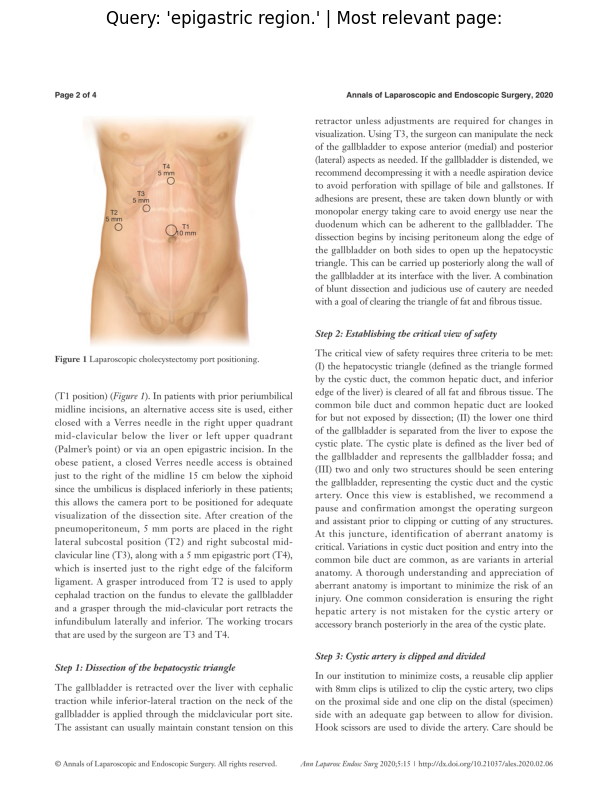

In [42]:
#load target page
pdf_path
doc = fitz.open(pdf_path)

best_idx = reranked[0][1]
target_page = chunk_lookup[best_idx]["page_number"] - 1
page = doc.load_page(target_page)


# Get the image of the page
img = page.get_pixmap(dpi=300)

doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))


plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off')
plt.show()

In [43]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query, convert_to_tensor=True)
    query_embedding = query_embedding/query_embedding.norm(p=2)    #L2-norm


    # Get dot products on embeddings
    dot_scores = util.dot_score(query_embedding, embeddings)[0]

    scores, indices = torch.topk(input=dot_scores, k=n_resources_to_return)

    return scores, indices


def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]= pages_and_chunks,
                                 n_resources_to_return: int=5):

    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Query: {query}\n")
    print("Results:")


    for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
        hit = chunk_lookup[idx]
        print(f"\nScore: {score.item():.4f}")
        print_wrapped(hit["chunk_text"])
        print(f"(Page {hit['page_number']}, chunk {hit['chunk_idx']})")

In [44]:
def retrieve_relevant_resources(
    query: str,
    embeddings: torch.Tensor,
    chunk_lookup: list,
    encoder_model: SentenceTransformer = embedding_model,
    reranker_tokenizer = reranker_tokenizer,
    reranker_model    = reranker_model,
    k_dense: int = 10,
    k_final: int = 5,            # num to return after rerank
) -> List[Tuple[float, int]]:
    """
    Returns top-k_final (rerank_score, chunk_index) tuples for a query.

    - Stage-1: dense cosine similarity over `embeddings`
    - Stage-2: cross-encoder reranking of top `k_dense`

    """

    # dense retrieval

    q_vec = encoder_model.encode(query, convert_to_tensor=True)
    q_vec = q_vec / q_vec.norm(p=2)

    cos_scores  = torch.mm(q_vec.unsqueeze(0), embeddings.T)[0]       # (N,)
    topk_dense  = torch.topk(cos_scores, k=k_dense)
    dense_idx   = topk_dense.indices.tolist()


    # cross-encoder rerank
    candidate_chunks = [chunk_lookup[i]["chunk_text"] for i in dense_idx]
    pairs            = [(query, chunk) for chunk in candidate_chunks]

    tokenized = reranker_tokenizer(
        pairs, padding=True, truncation=True, return_tensors="pt"
    ).to(reranker_model.device)

    with torch.no_grad():
        logits = reranker_model(**tokenized).logits.squeeze(-1).cpu()

    reranked = sorted(
        zip(logits, dense_idx),           # (score, original_index)
        key=lambda x: x[0],
        reverse=True
    )[:k_final]

    return reranked



def print_top_results_and_scores(
    query: str,
    embeddings: torch.Tensor,
    chunk_lookup: list = chunk_lookup,          # global from build step
    k_dense: int = 10,
    k_final: int = 5,
):
    """
    - Dense-retrieves `k_dense` token-chunks.
    - Cross-encoder reranks them, keeps `k_final`.
    - Nicely prints text, page, and chunk id.

    Requires:
        - `embeddings`  : (N_chunks, dim) tensor, L2-normalised
        - `chunk_lookup`: list[dict] with keys
            { chunk_text, page_number, chunk_idx }
    """

    # retrieval + rerank
    top_hits = retrieve_relevant_resources(
        query          = query,
        embeddings     = embeddings,
        chunk_lookup   = chunk_lookup,
        k_dense        = k_dense,
        k_final        = k_final,
    )

    print(f"\nFinal Reranked Results for '{query}'\n" + "-"*60)
    for score, idx in top_hits:
        hit = chunk_lookup[idx]
        print(f"\nRerank Score: {score.item():.4f}")
        print_wrapped(hit["chunk_text"])
        print(f"(Page {hit['page_number']}, chunk {hit['chunk_idx']})")


In [45]:
def show_page(
    query: str,
    pdf_path: '/content/drive/MyDrive/fMRIwork/ales.pdf',
    embeddings: torch.Tensor,
    chunk_lookup: List[Dict],
    k_dense: int = 10,
    k_final: int = 5,
    rerank_top1: bool = True,
) -> Tuple[int, List[Tuple[float, int]]]:


    doc  = fitz.open(pdf_path)

    # get reranked hits
    reranked = retrieve_relevant_resources(
        query        = query,
        embeddings   = embeddings,
        chunk_lookup = chunk_lookup,
        k_dense      = k_dense,
        k_final      = 5,
    )

    # best candidate
    best_idx = reranked[0][1]
    target_page = chunk_lookup[best_idx]["page_number"] - 1
    page = doc.load_page(target_page)

    # =render PDF page
    pix  = page.get_pixmap(dpi=300)
    doc.close()

    img_array = np.frombuffer(pix.samples_mv, dtype=np.uint8) \
                  .reshape(pix.h, pix.w, pix.n)

    plt.figure(figsize=(13, 10))
    plt.imshow(img_array)
    plt.title(f"Query: '{query}' | Page {target_page + 1}")
    plt.axis("off")
    plt.show()

    return target_page


In [46]:
query = "Gallbladder removal"

top_hits = retrieve_relevant_resources(query=query, embeddings=embeddings,chunk_lookup = chunk_lookup,k_dense= 10,k_final= 5)
top_hits

[(tensor(2.7586), 14),
 (tensor(2.3099), 13),
 (tensor(1.3543), 6),
 (tensor(0.8490), 5),
 (tensor(0.3856), 12)]

In [47]:
print_top_results_and_scores(query=query,embeddings = embeddings, k_dense = 10,k_final = 5)


Final Reranked Results for 'Gallbladder removal'
------------------------------------------------------------

Rerank Score: 2.7586
for retraction of the liver cephalad and clear visualization of the cystic plate to allow for any
needed hemostasis. The liver bed is irrigated and any blood or bile or aspirated from the field. The
gallbladder is then placed in an entrapment bag and removed at the 10–12 mm port site. Step 6:
Specimen and port removal Once the specimen is in the bag, it can be removed at the 10 mm port site
whether at the umbilicus or epigastric region. These steps are summarized in our video (Video 1).
Some enlargement of the skin and fascial opening may be needed, especially if there are multiple or
larger stones or a thickened gallbladder. Once the specimen is removed, all ports are vented to
eliminate any residual CO2 gas.
(Page 3, chunk 5)

Rerank Score: 2.3099
energy device to dissect gallbladder off the liver. Care should be taken to stay in the plane
between the g

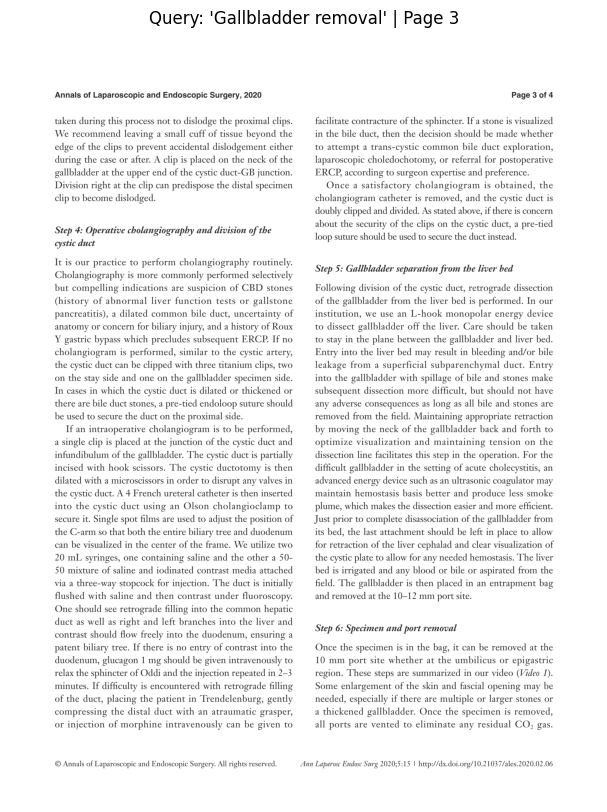

Best page: 2


In [48]:
retrieved_page = show_page(
    query       = query,
    pdf_path    = "/content/drive/MyDrive/fMRIwork/ales.pdf",
    embeddings  = embeddings,
    chunk_lookup= chunk_lookup,
    k_dense     = 10,
    k_final     = 5,
)
print("Best page:", retrieved_page)

In [49]:
gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2**30))
print(f"Available GPU memory: {gpu_memory_gb} GB")

Available GPU memory: 40 GB


In [50]:
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(model_id)

tokenizer = processor.tokenizer

config.json:   0%|          | 0.00/5.07k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/89.4k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.09k [00:00<?, ?B/s]

In [51]:
input_text = "What are the key steps involved in performing a safe laparoscopic cholecystectomy?"
print(f"Input text:\n{input_text}")
image = None  # Set to None - not multimodal yet


dialogue = [{"role": "user", "content": input_text}]
prompt = tokenizer.apply_chat_template(
    conversation=dialogue,
    tokenize=False,
    add_generation_prompt=True
)


inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")


output_ids = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.95
)


output_text = processor.tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0]

print("Model Output")
print(output_text)

Input text:
What are the key steps involved in performing a safe laparoscopic cholecystectomy?
Model Output
system

Cutting Knowledge Date: December 2023
Today Date: 10 Jul 2025

user

What are the key steps involved in performing a safe laparoscopic cholecystectomy?assistant

A laparoscopic cholecystectomy is a minimally invasive surgical procedure to remove the gallbladder. The key steps involved in performing a safe laparoscopic cholecystectomy are:

1. **Preoperative Preparation**:
   - The patient is given general anesthesia and positioned in a supine position.
   - The abdomen is cleaned and draped to minimize the risk of infection.
   - An intravenous line is inserted for administering fluids and medications.

2. **Port Placement**:
   - 3-4 small incisions (ports) are made in the abdomen, usually in the following locations:
     - One 10-12 mm port for the laparoscope (camera).
     - Two 5-10 mm ports for the surgical instruments (e.g., dissectors, graspers).
     - One additi

In [52]:
#Questions created by ChatGPT regarding laparoscopic cholecystectomy surgery
gpt_questions = [
"What are the key steps involved in performing a safe laparoscopic cholecystectomy?",
"What is the critical view of safety and why is it important during laparoscopic cholecystectomy?",
"What complications can arise from bile duct injury during laparoscopic cholecystectomy?",
"When is intraoperative cholangiography recommended during a laparoscopic cholecystectomy?",
"How is the patient positioned and what are the typical port placements for laparoscopic cholecystectomy?",
]


In [53]:
query = random.choice(gpt_questions)

print(f"Query: {query}")

# Get just the scores and indices of top related results
top_hits = retrieve_relevant_resources(query=query, embeddings=embeddings,chunk_lookup = chunk_lookup,k_dense= 10,k_final= 5)
top_hits

Query: What are the key steps involved in performing a safe laparoscopic cholecystectomy?


[(tensor(1.9042), 1),
 (tensor(1.2087), 2),
 (tensor(1.0576), 13),
 (tensor(0.3440), 8),
 (tensor(0.0319), 3)]

Augmenting the prompt with context items

In [54]:
def prompt_formatter(query: str,
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    context = "- " + "\n- ".join([item["token_chunks"] for item in context_items])

    # Create a base prompt
    base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

\nExample 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of life, and legal issues.
\nExample 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety helps prevent injury to the bile duct by making sure the anatomy is clearly identified before cutting. It requires three things: Clearing the hepatocystic triangle of fat and tissue, Separating the lower third of the gallbladder from the liver, and Seeing only two structures entering the gallbladder (the cystic duct and artery).
\nExample 3:
Query: What are the indications for using a pre-tied endoloop suture instead of clips on the cystic duct?
Answer: A pre-tied endoloop suture is used instead of clips when the cystic duct is dilated or thickened, or if bile duct stones are present, because it provides a more secure closure than standard clips in these cases.
\nNow use the following context items to answer the user query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    # Update base prompt with context items and query
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

In [55]:
query = random.choice(gpt_questions)
query = "What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?"
print(f"Query: {query}")

# Get relevant resources
top_hits = retrieve_relevant_resources(query=query, embeddings=embeddings,chunk_lookup = chunk_lookup,k_dense= 10,k_final= 5)

# Create a list of context items
context_items = [{"token_chunks": chunk_lookup[idx]["chunk_text"]} for _, idx in top_hits]

# Format prompt with context items
prompt = prompt_formatter(query=query,context_items=context_items)
print(prompt)

Query: What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Jul 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.


Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of life, and legal issues.

Example 2:
Query: Why is the critical view

In [56]:
input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(**input_ids,
                             temperature=0.7,
                             do_sample=True,
                             max_new_tokens=256)

output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?
RAG answer:
<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Jul 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.


Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of life, and legal issues.

Example 2:
Qu

In [57]:
def ask(
    query: str,
    *,
    temperature: float  = 0.3,
    max_new_tokens: int = 256,
    k_dense: int       = 20,            # dense pool size
    k_final: int       = 5,             # after rerank
    return_meta: bool  = False,
) -> str | tuple[str, list[dict]]:
    """
    - Dense+cross-encoder retrieval
    - Prompt assembly  (query + top-k chunks)
    - LLM generation

    Returns answer (str) or (answer, context_items) if `return_meta=True`.
    """

    # retrieval
    top_hits = retrieve_relevant_resources(
        query          = query,
        embeddings     = embeddings,       # global tensor
        chunk_lookup   = chunk_lookup,     # global metadata
        k_dense        = k_dense,
        k_final        = k_final,
    )

    context_items = [
        {
            "token_chunks": chunk_lookup[idx]["chunk_text"],
            "score"       : float(score),
            "page"        : chunk_lookup[idx]["page_number"],
        }
        for score, idx in top_hits
    ]

    # prompt construction
    prompt = prompt_formatter(query=query, context_items=context_items)

    ctx_limit = getattr(model.config, "max_position_embeddings",
                    tokenizer.model_max_length)        # ← fallback

    enc = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=ctx_limit,
    ).to(model.device)

    # generation
    with torch.no_grad():
        gen_out = model.generate(
            **enc,
            temperature=temperature,
            do_sample=temperature > 0,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
        )

    answer = tokenizer.decode(gen_out[0],
                              skip_special_tokens=True).replace(prompt, "").strip()

    # clean-up
    junk_phrases = [
        "Sure, here is the answer to the user query:",
        "Certainly. ",
    ]
    for jp in junk_phrases:
        answer = answer.replace(jp, "")
    answer = answer.replace("\n\n\n", "\n\n").strip()

    if return_meta:
        return answer, context_items
    return answer


In [58]:
ans, meta = ask(
    "What are the three criteria for the critical view of safety?",
    temperature=0.2,
    return_meta=True,
)
print(ans)
print("\nSources:")
for m in meta:
    print(f"• Page {m['page']}  (score {m['score']:.3f})")

system

Cutting Knowledge Date: December 2023
Today Date: 10 Jul 2025

user

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of life, and legal issues.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety helps prevent injury to the bile duct by making sure the anatomy is clearly identified before cutting. It requires three things: Clear

In [59]:
ans, meta = ask(
    "During a laparoscopic cholecystectomy, what routine or selective indications do the authors give for performing an intra-operative cholangiogram, and how is the cystic duct prepared for catheter insertion?",
    temperature=0.2,
    return_meta=True,
)
print(ans)
print("\nSources:")
for m in meta:
    print(f"• Page {m['page']}  (score {m['score']:.3f})")

system

Cutting Knowledge Date: December 2023
Today Date: 10 Jul 2025

user

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of life, and legal issues.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety helps prevent injury to the bile duct by making sure the anatomy is clearly identified before cutting. It requires three things: Clear

#Evaluation

In [63]:
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [64]:
query_pool = [
    "What are the three criteria that define the critical view of safety?",
    "When do the authors recommend performing an intra-operative cholangiogram?",
    "List common complications after laparoscopic cholecystectomy.",
    "Which energy device is preferred for retrograde dissection of the gallbladder?",
    "How is the patient positioned to facilitate cholangiography?",
    "What clip strategy is used for the cystic artery?",
]

In [65]:
client = openai.AsyncOpenAI(api_key=os.environ["OPENAI_API_KEY"])
gpt_model = "gpt-4o-mini"
encoder = tiktoken.encoding_for_model(gpt_model)
rpm_limit = 3
limiter = AsyncLimiter(rpm_limit, time_period=60)

In [67]:
async def judge(prompt: str, max_tokens: int = 1, temperature: float = 0.0):
    async with limiter:        # blocks until a slot is free
        resp = await client.chat.completions.create(
            model=gpt_model,
            temperature=temperature,
            max_tokens=max_tokens,
            messages=[
                {"role": "system",
                 "content": "You are a strict evaluator. "
                            "Answer ONLY with the requested rating/number."},
                {"role": "user", "content": prompt}
            ],
        )
    return resp.choices[0].message.content.strip()

In [68]:
async def context_precision(query: str, chunk_texts: list[str]) -> float:
    """
    Returns Precision@k for given chunks using GPT-4o.
    """
    tasks, ratings = [], []
    template = ("Question: {q}\n\nChunk:\n\"\"\"{c}\"\"\"\n\n"
                "Does this chunk help answer the question? Reply only YES or NO.")

    for c in chunk_texts:
        tasks.append(judge(template.format(q=query, c=c.upper()[:4096])))
    for r in await asyncio.gather(*tasks):
        ratings.append(1.0 if r.lower().startswith("y") else 0.0)
    return sum(ratings) / len(ratings)

In [69]:
async def fluency_coherence(answer: str) -> dict:
    prompt = (
        "Rate the answer below on a 1-5 integer scale for each trait.\n\n"
        "Traits: (A) Fluency/Grammar, (B) Coherence/Logical-flow.\n\n"
        "Return JSON exactly like {\"fluency\":4, \"coherence\":5}.\n\n"
        f"Answer:\n\"\"\"{answer[:4096]}\"\"\""
    )
    import json
    resp = await judge(prompt, max_tokens=20)
    try:
        return json.loads(resp)
    except Exception:
        return {"fluency": 1, "coherence": 1}

In [70]:
async def faithfulness_score(answer: str, context: str) -> float:
    prompt = (
        "Context:\n\"\"\"{ctx}\"\"\"\n\nAnswer:\n\"\"\"{ans}\"\"\"\n\n"
        "Does the Context completely support every factual claim in the Answer?\n"
        "Respond with a single number between 0 (no support) and 1 (fully supported)."
    ).format(ctx=context[:4096], ans=answer[:2048])

    resp = await judge(prompt, max_tokens=3)
    try:
        return float(resp.split()[0])
    except ValueError:
        return 0.0

In [72]:
async def evaluate_queries(query_pool: list[str],
                           k_dense=20, k_final=5) -> None:
    latencies, precisions, flu, coh, halluc = [], [], [], [], []

    for query in query_pool:
        # latency
        t0 = time.perf_counter()

        # RAG answer + context
        answer, ctx = ask(query,
                          k_dense=k_dense,
                          k_final=k_final,
                          temperature=0.2,
                          return_meta=True)
        latency = time.perf_counter() - t0
        latencies.append(latency)

        chunks = [c["token_chunks"] for c in ctx]
        joined = "\n\n".join(chunks)

        prec  = await context_precision(query, chunks)
        fc    = await fluency_coherence(answer)
        faith = await faithfulness_score(answer, joined)

        precisions.append(prec)
        flu.append(fc["fluency"])
        coh.append(fc["coherence"])
        halluc.append(1 if faith < 0.3 else 0)

        print(f"{query[:40]:<40}  lat {latency:4.2f}s  prec {prec:.2f}  "
              f"faith {faith:.2f}")

    # summary
    print("\n──────────── Summary (GPT-4o judge) ────────────")
    print(f"Avg latency        : {statistics.mean(latencies):.2f}s  "
          f"(p99 {max(latencies):.2f}s)")
    print(f"Precision@{k_final}: {statistics.mean(precisions):.3f}")
    print(f"Fluency (1-5)      : {statistics.mean(flu):.2f}")
    print(f"Coherence (1-5)    : {statistics.mean(coh):.2f}")
    print(f"Hallucination rate : {100*sum(halluc)/len(halluc):.1f}%")


nest_asyncio.apply()
random.seed(42)
SAMPLE_QUERIES = random.sample(query_pool, k=min(30, len(query_pool)))


await evaluate_queries(SAMPLE_QUERIES)

What clip strategy is used for the cysti  lat 10.86s  prec 0.80  faith 1.00
What are the three criteria that define   lat 11.27s  prec 0.20  faith 1.00
How is the patient positioned to facilit  lat 10.43s  prec 0.40  faith 1.00
List common complications after laparosc  lat 10.55s  prec 0.60  faith 1.00
When do the authors recommend performing  lat 11.99s  prec 0.40  faith 1.00
Which energy device is preferred for ret  lat 10.17s  prec 0.40  faith 0.00

──────────── Summary (GPT-4o judge) ────────────
Avg latency        : 10.88s  (p99 11.99s)
Precision@5: 0.467
Fluency (1-5)      : 3.33
Coherence (1-5)    : 3.50
Hallucination rate : 16.7%
